<a href="https://colab.research.google.com/github/Mariacmv/Faculdade/blob/main/fuzzy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Readme.md
## Detecção Inteligente de Spam Utilizando Machine Learning e Lógica Fuzzy

## Integrantes
- Maria Clara Guerreira Moita Viana
- Maria Fernanda Lopes Rodrigues de Sousa
- João Gabriel Leite Neirelli
- João Victor Martins Albernaz


## Objetivo

Desenvolver um sistema capaz de identificar mensagens SMS classificando-as como Spam ou Não Spam através de Machine Learning e complementar essa análise utilizando Lógica Fuzzy para determinar o grau de suspeita da mensagem.

## Tecnologias Utilizadas

- Python
- Google Colab
- Pandas
- NumPy
- Scikit-Learn
- Scikit-Fuzzy
- Matplotlib

## Fluxo da Solução

Mensagem SMS

⬇️

Pré-processamento (TF-IDF)

⬇️

Árvore de Decisão

⬇️

Probabilidade de Spam

⬇️

Sistema Fuzzy

⬇️

Grau de Suspeita

## Base de Dados

SMS Spam Collection Dataset

- Total de mensagens: 5572
- Classes:
  - Spam
    - Ham (Não Spam)

    ## Metodologia

    ### Machine Learning
    - Vetorização de texto com TF-IDF
    - Treinamento usando Árvore de Decisão
    - Avaliação por matriz de confusão e métricas de classificação

  ### Sistema Fuzzy
    Entradas:
    - Probabilidade de Spam
    - Quantidade de Links

    Saída:
    - Grau de Suspeita

  ## Resultado Esperado

    O sistema deve identificar mensagens suspeitas e fornecer uma avaliação mais interpretável através da integração entre Machine Learning e Lógica Fuzzy.

Importando os dados

Importando libs

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

Criando o dataframe


In [ ]:
df = pd.read_csv("/content/spam.csv", encoding="latin-1")
df.head()

#remova colunas vazias
df = df[['v1', 'v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Criando vetores numéricos para o programa

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["v2"])

Resposta correta e conversão

In [ ]:
y = df["v1"].map({
    "ham": 0,
    "spam": 1
})

Treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Árvore

In [ ]:
modelo = DecisionTreeClassifier(random_state=42)

Treinando

In [ ]:
modelo.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Previsões

In [ ]:
y_pred = modelo.predict(X_test)

Calculando métricas

In [ ]:
#acurácia
print("Acurácia:", accuracy_score(y_test, y_pred))

#precisão
print("Precisão:", precision_score(y_test, y_pred))

#recall
print("Recall:", recall_score(y_test, y_pred))

#f1-score
print("F1:", f1_score(y_test, y_pred))

Acurácia: 0.9668161434977578
Precisão: 0.8896551724137931
Recall: 0.86
F1: 0.8745762711864407


Matriz de confusão

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()



---



# Implementando o Fuzzy

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.4 MB/s eta 0:00:00


Importando libs

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Variáveis fuzzy

In [ ]:
links = ctrl.Antecedent(np.arange(0, 11, 1), 'links')
palavras = ctrl.Antecedent(np.arange(0, 11, 1), 'palavras')
suspeita = ctrl.Consequent(np.arange(0, 101, 1), 'suspeita')

Funções de pertinência

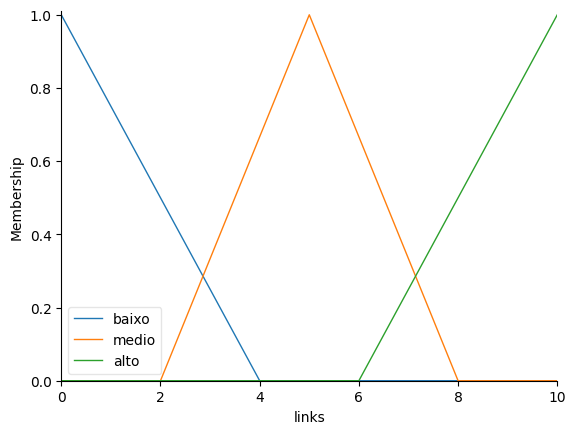

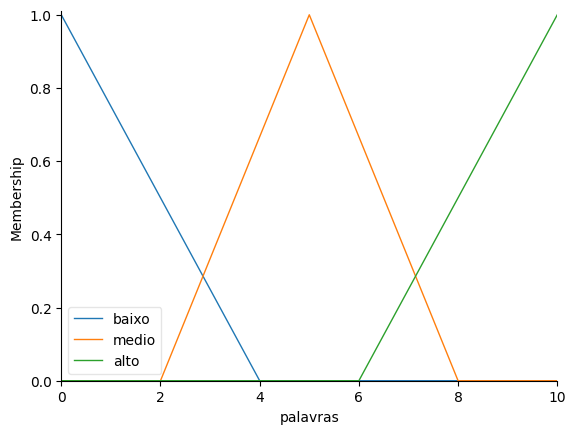

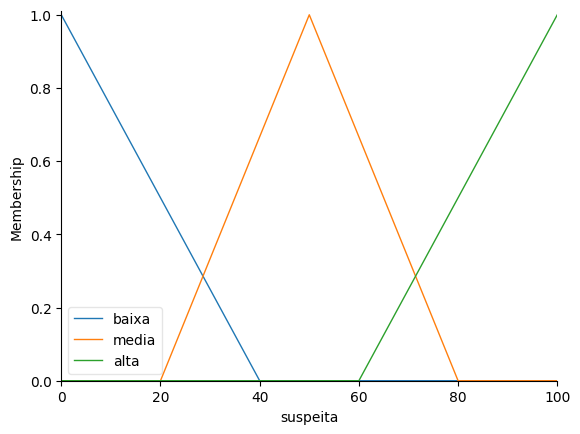

In [ ]:
#links
links['baixo'] = fuzz.trimf(links.universe, [0, 0, 4])
links['medio'] = fuzz.trimf(links.universe, [2, 5, 8])
links['alto'] = fuzz.trimf(links.universe, [6, 10, 10])

#palavras suspeitas
palavras['baixo'] = fuzz.trimf(palavras.universe, [0, 0, 4])
palavras['medio'] = fuzz.trimf(palavras.universe, [2, 5, 8])
palavras['alto'] = fuzz.trimf(palavras.universe, [6, 10, 10])

#grau de suspeita
suspeita['baixa'] = fuzz.trimf(suspeita.universe, [0, 0, 40])
suspeita['media'] = fuzz.trimf(suspeita.universe, [20, 50, 80])
suspeita['alta'] = fuzz.trimf(suspeita.universe, [60, 100, 100])

#gráficos
links.view()
palavras.view()
suspeita.view()

Regras

In [ ]:
regra1 = ctrl.Rule(links['alto'] & palavras['alto'], suspeita['alta'])

regra2 = ctrl.Rule(links['alto'] & palavras['medio'], suspeita['alta'])

regra3 = ctrl.Rule(links['medio'] & palavras['alto'], suspeita['alta'])

regra4 = ctrl.Rule(links['medio'] & palavras['medio'], suspeita['media'])

regra5 = ctrl.Rule(links['baixo'] & palavras['medio'], suspeita['media'])

regra6 = ctrl.Rule(links['baixo'] & palavras['baixo'], suspeita['baixa'])

Sistema

In [ ]:
sistema = ctrl.ControlSystem([
    regra1,
    regra2,
    regra3,
    regra4,
    regra5,
    regra6
])

simulador = ctrl.ControlSystemSimulation(sistema)

Teste:
mensagem com 8 links e 9 palavras suspeitas

In [ ]:
simulador.input['links'] = 8
simulador.input['palavras'] = 9

simulador.compute()

print(simulador.output['suspeita'])

84.44444444444444


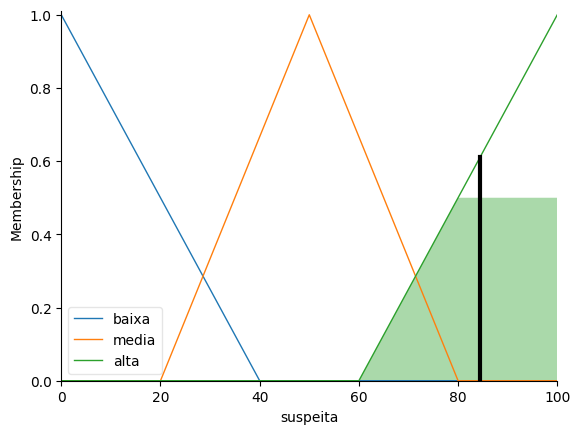

In [ ]:
#resultado
suspeita.view(sim=simulador)